# Tutorial 02: Verification Binaries

**Workshop: ML for Galactic Binary Search & Parameter Estimation**

---

## Project Goal

**Test ML methods on known astrophysical sources** — Verification Binaries (VBs) are compact binaries with known parameters from electromagnetic observations. They provide ground truth for validating our methods.

---

## Learning Outcomes (~30 min)

1. Understand what verification binaries are and why they matter
2. Map real VB parameters to our toy model framework
3. Inject "scaled" VBs and test recovery
4. Identify what's needed for real VB analysis

---

In [1]:
# ================================================================
# Setup
# ================================================================
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
import torch
import torch.nn.functional as F

from src.dataset import MultiSinusoidDataset
from src.model import SlotFlow

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


In [2]:
# ================================================================
# Load Model
# ================================================================

config_path = "../pretrained_model/test_clariden/model_config.pt"
ckpt_dir = "../pretrained_model/test_clariden/checkpoints"

config = torch.load(config_path, map_location="cpu")

ckpt_files = [f for f in os.listdir(ckpt_dir) if f.endswith(".ckpt")]
ckpt_path = os.path.join(ckpt_dir, sorted(ckpt_files)[-1])
ckpt = torch.load(ckpt_path, map_location="cpu")
state_dict = {k.replace("model.", "").replace("_orig_mod.", ""): v 
              for k, v in ckpt["state_dict"].items()}

model = SlotFlow(
    hidden_dim=config["hidden_dim"],
    max_slots=config["max_slots"],
    flow_depth=config.get("flow_depth", 8),
    use_noise_encoder=config.get("use_noise_encoder", False),
)
model.load_state_dict(state_dict, strict=True)
model.to(device).eval()

FREQ_RANGE = config["freq_range"]
T_LONG = config["tEnd_long"]

print(f"Model loaded.")

/var/folders/sr/n2fcp1f90810jp4b_lrryl700000gn/T/ipykernel_25701/899079745.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  config = torch.load(config_path, map_location=

Model loaded.


## 1. What are Verification Binaries?

Verification binaries are compact binary systems (mostly white dwarf pairs) that:
- Have been observed electromagnetically (optical, X-ray)
- Have measured orbital parameters (period, inclination, sky location)
- Will be **guaranteed** LISA detections
- Provide **ground truth** for validating data analysis pipelines

There are ~50 known VBs that LISA should detect.

In [3]:
# ================================================================
# Catalog of Known Verification Binaries
# ================================================================

# Real verification binary data (subset)
# GW frequency = 2 × orbital frequency

VERIFICATION_BINARIES = {
    # Name: {f_gw (mHz), amplitude (strain), period (s), distance (kpc), type}
    "HM Cnc": {
        "f_gw_mHz": 6.22,
        "period_s": 321.5,
        "distance_kpc": 5.0,
        "type": "AM CVn",
        "strain": 1.3e-22,
    },
    "V407 Vul": {
        "f_gw_mHz": 3.51,
        "period_s": 569.4,
        "distance_kpc": 1.8,
        "type": "AM CVn",
        "strain": 1.8e-22,
    },
    "ES Cet": {
        "f_gw_mHz": 3.22,
        "period_s": 620.2,
        "distance_kpc": 1.0,
        "type": "AM CVn",
        "strain": 3.5e-22,
    },
    "AM CVn": {
        "f_gw_mHz": 1.94,
        "period_s": 1028.7,
        "distance_kpc": 0.3,
        "type": "AM CVn",
        "strain": 1.5e-21,
    },
    "HP Lib": {
        "f_gw_mHz": 1.81,
        "period_s": 1102.7,
        "distance_kpc": 0.2,
        "type": "AM CVn",
        "strain": 2.1e-21,
    },
    "SDSS J0651": {
        "f_gw_mHz": 2.61,
        "period_s": 765.5,
        "distance_kpc": 1.0,
        "type": "DWD",
        "strain": 4.0e-22,
    },
    "SDSS J0935": {
        "f_gw_mHz": 1.62,
        "period_s": 1234.6,
        "distance_kpc": 0.6,
        "type": "DWD",
        "strain": 8.0e-22,
    },
    "ZTF J1539": {
        "f_gw_mHz": 4.82,
        "period_s": 414.8,
        "distance_kpc": 2.4,
        "type": "DWD",
        "strain": 2.3e-22,
    },
}

# Display catalog
print("="*70)
print("VERIFICATION BINARY CATALOG (subset)")
print("="*70)
print(f"{'Name':<15} {'f_gw [mHz]':<12} {'Period [s]':<12} {'D [kpc]':<10} {'Type':<10}")
print("-"*70)
for name, params in VERIFICATION_BINARIES.items():
    print(f"{name:<15} {params['f_gw_mHz']:<12.2f} {params['period_s']:<12.1f} {params['distance_kpc']:<10.1f} {params['type']:<10}")

VERIFICATION BINARY CATALOG (subset)
Name            f_gw [mHz]   Period [s]   D [kpc]    Type      
----------------------------------------------------------------------
HM Cnc          6.22         321.5        5.0        AM CVn    
V407 Vul        3.51         569.4        1.8        AM CVn    
ES Cet          3.22         620.2        1.0        AM CVn    
AM CVn          1.94         1028.7       0.3        AM CVn    
HP Lib          1.81         1102.7       0.2        AM CVn    
SDSS J0651      2.61         765.5        1.0        DWD       
SDSS J0935      1.62         1234.6       0.6        DWD       
ZTF J1539       4.82         414.8        2.4        DWD       


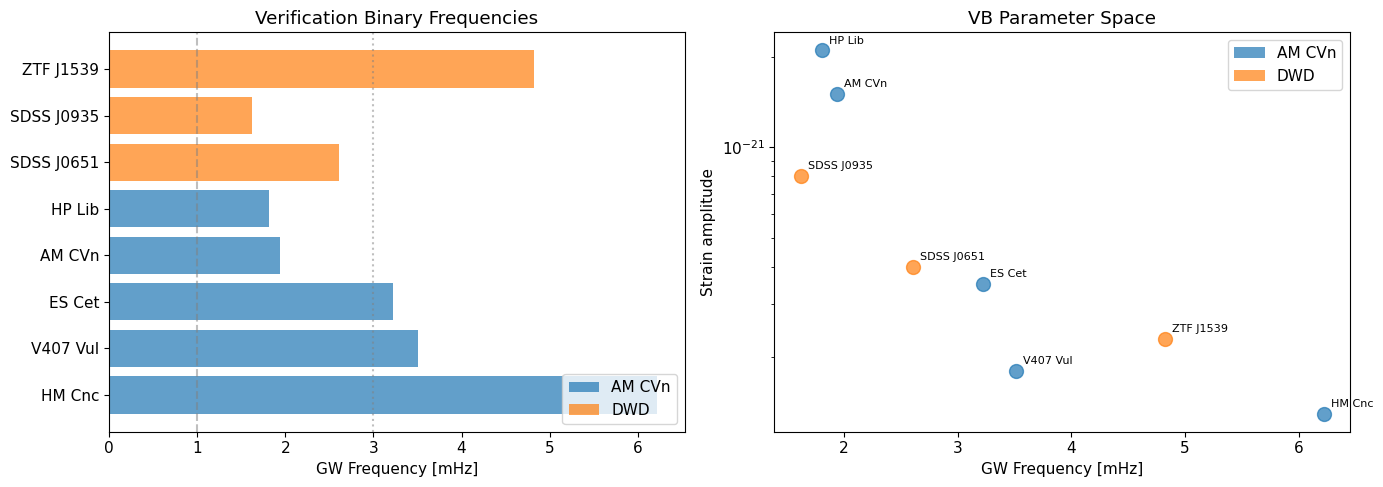

In [4]:
# ================================================================
# Visualize VB Frequency Distribution
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Frequency distribution
ax = axes[0]
freqs = [vb['f_gw_mHz'] for vb in VERIFICATION_BINARIES.values()]
names = list(VERIFICATION_BINARIES.keys())
colors = ['C0' if VERIFICATION_BINARIES[n]['type'] == 'AM CVn' else 'C1' for n in names]

ax.barh(names, freqs, color=colors, alpha=0.7)
ax.set_xlabel('GW Frequency [mHz]')
ax.set_title('Verification Binary Frequencies')
ax.axvline(1, color='gray', ls='--', alpha=0.5, label='1 mHz')
ax.axvline(3, color='gray', ls=':', alpha=0.5, label='3 mHz')

# Add legend for types
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='C0', alpha=0.7, label='AM CVn'),
                   Patch(facecolor='C1', alpha=0.7, label='DWD')]
ax.legend(handles=legend_elements, loc='lower right')

# 2. Frequency vs strain
ax = axes[1]
for name, vb in VERIFICATION_BINARIES.items():
    color = 'C0' if vb['type'] == 'AM CVn' else 'C1'
    ax.scatter(vb['f_gw_mHz'], vb['strain'], s=100, c=color, alpha=0.7)
    ax.annotate(name, (vb['f_gw_mHz'], vb['strain']), fontsize=8, 
                xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('GW Frequency [mHz]')
ax.set_ylabel('Strain amplitude')
ax.set_yscale('log')
ax.set_title('VB Parameter Space')
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## 2. Mapping VBs to SlotFlow's Toy Model

**Challenge**: SlotFlow operates at 2.5-3.0 Hz, while VBs are at 1-7 mHz.

**Approach**: Create "scaled VBs" that preserve the *relative* properties:
- Relative frequency separations (as fractions of bandwidth)
- Relative amplitudes (as SNR ratios)
- Number of sources

In [5]:
# ================================================================
# VB Scaling Functions
# ================================================================

def scale_vb_to_toy(vb_freq_mHz, vb_strain, 
                    toy_freq_range=(2.5, 3.0), toy_amp_range=(0.5, 1.5)):
    """
    Scale a VB's parameters to the toy model frequency range.
    
    We map the LISA band (0.1-10 mHz) to SlotFlow's band (2.5-3.0 Hz)
    preserving the relative position within the band.
    
    Parameters
    ----------
    vb_freq_mHz : float
        VB frequency in mHz
    vb_strain : float
        VB strain amplitude
    toy_freq_range : tuple
        SlotFlow frequency range
    toy_amp_range : tuple
        SlotFlow amplitude range
    
    Returns
    -------
    toy_freq : float
        Scaled frequency in Hz
    toy_amp : float
        Scaled amplitude
    """
    # LISA VB band approximately 0.5-8 mHz
    lisa_band = (0.5, 8.0)  # mHz
    
    # Map frequency (linear scaling)
    frac = (vb_freq_mHz - lisa_band[0]) / (lisa_band[1] - lisa_band[0])
    frac = np.clip(frac, 0, 1)
    toy_freq = toy_freq_range[0] + frac * (toy_freq_range[1] - toy_freq_range[0])
    
    # Map amplitude (log scaling, since strains span orders of magnitude)
    # Brightest VB: ~1e-21, faintest: ~1e-22
    strain_range = (1e-22, 2e-21)
    log_frac = (np.log10(vb_strain) - np.log10(strain_range[0])) / \
               (np.log10(strain_range[1]) - np.log10(strain_range[0]))
    log_frac = np.clip(log_frac, 0, 1)
    toy_amp = toy_amp_range[0] + log_frac * (toy_amp_range[1] - toy_amp_range[0])
    
    return toy_freq, toy_amp

# Scale all VBs
print("="*70)
print("SCALED VERIFICATION BINARIES (mapped to SlotFlow range)")
print("="*70)
print(f"{'Name':<15} {'Real f [mHz]':<14} {'Toy f [Hz]':<12} {'Real strain':<14} {'Toy amp':<10}")
print("-"*70)

scaled_vbs = {}
for name, vb in VERIFICATION_BINARIES.items():
    toy_f, toy_a = scale_vb_to_toy(vb['f_gw_mHz'], vb['strain'])
    scaled_vbs[name] = {'freq': toy_f, 'amp': toy_a, 'original': vb}
    print(f"{name:<15} {vb['f_gw_mHz']:<14.2f} {toy_f:<12.4f} {vb['strain']:<14.2e} {toy_a:<10.3f}")

SCALED VERIFICATION BINARIES (mapped to SlotFlow range)
Name            Real f [mHz]   Toy f [Hz]   Real strain    Toy amp   
----------------------------------------------------------------------
HM Cnc          6.22           2.8813       1.30e-22       0.588     
V407 Vul        3.51           2.7007       1.80e-22       0.696     
ES Cet          3.22           2.6813       3.50e-22       0.918     
AM CVn          1.94           2.5960       1.50e-21       1.404     
HP Lib          1.81           2.5873       2.10e-21       1.500     
SDSS J0651      2.61           2.6407       4.00e-22       0.963     
SDSS J0935      1.62           2.5747       8.00e-22       1.194     
ZTF J1539       4.82           2.7880       2.30e-22       0.778     


## 3. Injecting Scaled VBs

Let's inject a few "scaled VBs" into our toy model and test if SlotFlow can recover them.

In [6]:
# ================================================================
# VB Injection Function
# ================================================================

def inject_vbs(vb_names, noise_std=0.3, seed=42):
    """
    Inject multiple scaled VBs into a signal.
    
    Parameters
    ----------
    vb_names : list of str
        Names of VBs to inject
    noise_std : float
        Noise level
    seed : int
        Random seed
    
    Returns
    -------
    x_long, x_short : tensors
        Signal streams
    true_params : tensor
        True parameters [A, phi, f] for each VB
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    # Time arrays
    t_long = torch.linspace(0, T_LONG, config["num_samples_long"])
    t_short = torch.linspace(0, config["tEnd_short"], config["num_samples_short"])
    
    x_long = torch.zeros_like(t_long)
    x_short = torch.zeros_like(t_short)
    
    params_list = []
    
    for name in vb_names:
        vb = scaled_vbs[name]
        f = vb['freq']
        A = vb['amp']
        phi = np.random.uniform(0, 2*np.pi)
        
        x_long += A * torch.sin(2*np.pi*f*t_long + phi)
        x_short += A * torch.sin(2*np.pi*f*t_short + phi)
        
        params_list.append([A, phi, f])
    
    # Add noise
    x_long += torch.randn_like(t_long) * noise_std
    x_short += torch.randn_like(t_short) * noise_std
    
    true_params = torch.tensor(params_list)
    
    return x_long.float(), x_short.float(), true_params

# Test with 3 VBs
test_vbs = ["HM Cnc", "AM CVn", "SDSS J0651"]
x_long, x_short, true_params = inject_vbs(test_vbs, noise_std=0.3)

print(f"Injected {len(test_vbs)} VBs:")
for i, name in enumerate(test_vbs):
    A, phi, f = true_params[i].tolist()
    print(f"  {name}: f={f:.4f} Hz, A={A:.3f}")

Injected 3 VBs:
  HM Cnc: f=2.8813 Hz, A=0.588
  AM CVn: f=2.5960 Hz, A=1.404
  SDSS J0651: f=2.6407 Hz, A=0.963


In [7]:
# ================================================================
# Run Inference on VB Injection
# ================================================================

@torch.no_grad()
def analyze_vb_injection(model, x_long, x_short, true_params, vb_names, n_samples=3000):
    """
    Run SlotFlow on VB injection and compare to ground truth.
    """
    # Forward pass
    x_l = x_long.unsqueeze(0).to(device)
    x_s = x_short.unsqueeze(0).to(device)
    output = model(x_l, x_s)
    
    k_pred = output['K_pred'].item()
    k_true = len(vb_names)
    k_probs = F.softmax(output['K_logits'], dim=-1).cpu().numpy().squeeze()
    
    # Sample posteriors
    context = output['context']
    freq_center = (FREQ_RANGE[0] + FREQ_RANGE[1]) / 2
    
    posteriors = []
    for k in range(k_pred):
        samples = model.flow.sample(n_samples, context=context[k:k+1])
        samples = samples.squeeze(0).cpu()
        
        amp = samples[:, 0].numpy()
        phase = torch.atan2(samples[:, 2], samples[:, 1]).numpy() % (2*np.pi)
        freq = (samples[:, 3].numpy() / 3.0) + freq_center
        
        posteriors.append({'amp': amp, 'phase': phase, 'freq': freq,
                          'freq_mean': np.mean(freq), 'amp_mean': np.mean(amp)})
    
    return {
        'k_true': k_true,
        'k_pred': k_pred,
        'k_probs': k_probs,
        'posteriors': posteriors,
        'true_params': true_params,
        'vb_names': vb_names,
    }

results = analyze_vb_injection(model, x_long, x_short, true_params, test_vbs)

print(f"\nK prediction: {results['k_pred']} (true: {results['k_true']})")
print(f"K correct: {'Yes' if results['k_pred'] == results['k_true'] else 'No'}")


K prediction: 3 (true: 3)
K correct: Yes


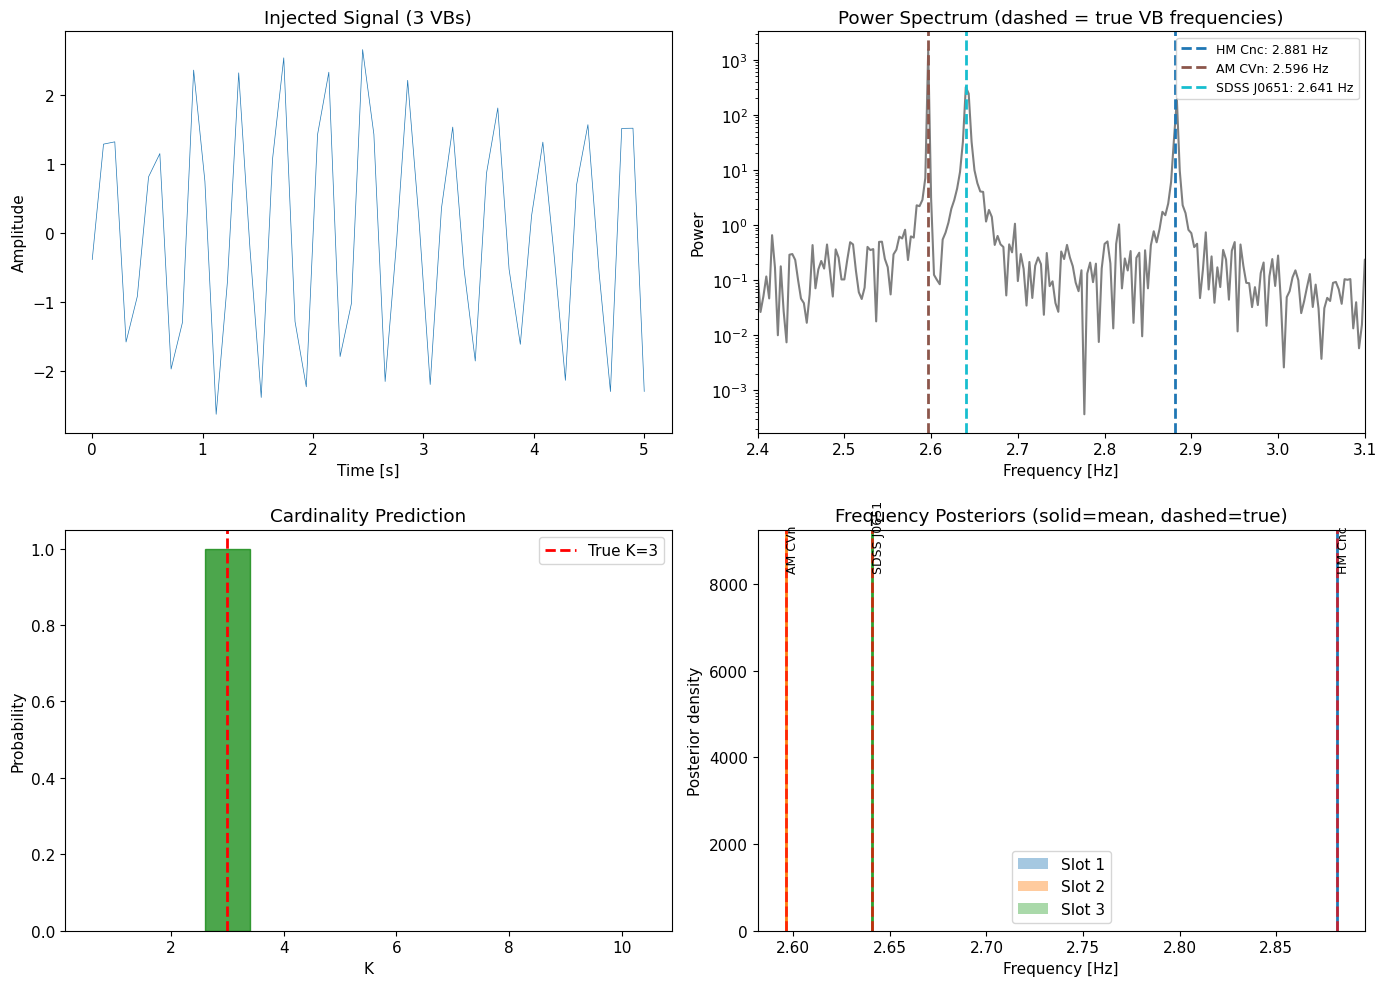

In [8]:
# ================================================================
# Visualize VB Recovery
# ================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Signal and spectrum
ax = axes[0, 0]
t = np.linspace(0, 5, 500)  # First 5 seconds
t_idx = int(5 * config["num_samples_long"] / T_LONG)
ax.plot(np.linspace(0, 5, t_idx), x_long[:t_idx].numpy(), linewidth=0.5)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude')
ax.set_title(f'Injected Signal ({len(test_vbs)} VBs)')

# 2. Power spectrum with true frequencies
ax = axes[0, 1]
freqs = np.fft.rfftfreq(len(x_long), d=T_LONG/len(x_long))
power = np.abs(np.fft.rfft(x_long.numpy()))**2 / len(x_long)
ax.semilogy(freqs, power, 'k-', alpha=0.5)

colors = plt.cm.tab10(np.linspace(0, 1, len(test_vbs)))
for i, name in enumerate(test_vbs):
    f_true = true_params[i, 2].item()
    ax.axvline(f_true, color=colors[i], ls='--', lw=2, label=f'{name}: {f_true:.3f} Hz')

ax.set_xlim(FREQ_RANGE[0]-0.1, FREQ_RANGE[1]+0.1)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Power')
ax.set_title('Power Spectrum (dashed = true VB frequencies)')
ax.legend(fontsize=9)

# 3. K probability
ax = axes[1, 0]
k_vals = np.arange(1, len(results['k_probs']) + 1)
bars = ax.bar(k_vals, results['k_probs'], color='steelblue', alpha=0.7)
bars[results['k_pred']-1].set_color('green')
ax.axvline(results['k_true'], color='red', ls='--', lw=2, label=f'True K={results["k_true"]}')
ax.set_xlabel('K')
ax.set_ylabel('Probability')
ax.set_title('Cardinality Prediction')
ax.legend()

# 4. Frequency posteriors vs true
ax = axes[1, 1]
for k, post in enumerate(results['posteriors']):
    ax.hist(post['freq'], bins=50, alpha=0.4, density=True, label=f'Slot {k+1}')
    ax.axvline(post['freq_mean'], color=f'C{k}', ls='-', lw=2)

for i, name in enumerate(test_vbs):
    f_true = true_params[i, 2].item()
    ax.axvline(f_true, color='red', ls='--', lw=2, alpha=0.7)
    ax.annotate(name, (f_true, ax.get_ylim()[1]*0.9), rotation=90, fontsize=9)

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Posterior density')
ax.set_title('Frequency Posteriors (solid=mean, dashed=true)')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Systematic VB Recovery Test

Let's test recovery for different VB combinations.

In [9]:
# ================================================================
# Systematic VB Recovery Experiment (with Hungarian Matching)
# ================================================================

from itertools import combinations

def hungarian_match(model, context, true_params, K_pred, freq_center):
    """
    Compute Hungarian matching between slots and true sources.
    Uses flow log-prob as cost (consistent with training).
    """
    true_k = len(true_params)
    
    # Convert true params to flow representation (ensure float32)
    if torch.is_tensor(true_params):
        tp = true_params.float()
    else:
        tp = torch.tensor(true_params, dtype=torch.float32)
    
    amp = tp[:, 0]
    phi = tp[:, 1]
    freq = tp[:, 2]
    true_params_4d = torch.stack(
        [amp, torch.cos(phi), torch.sin(phi), freq], dim=1
    ).to(device)
    
    # Apply normalization (same as training)
    gt_weighted = true_params_4d.clone()
    gt_weighted[:, 1:3] *= 2
    gt_weighted[:, 3] -= freq_center
    gt_weighted[:, 3] *= 3
    
    # Compute cost matrix
    ctx_exp = context.unsqueeze(0).expand(true_k, -1, -1)
    gt_exp = gt_weighted.unsqueeze(1).expand(-1, K_pred, -1)
    all_ctx = ctx_exp.reshape(-1, context.shape[-1])
    all_gt = gt_exp.reshape(-1, gt_weighted.shape[-1])
    
    logp = model.flow.log_prob(all_gt, context=all_ctx)
    cost = -logp.view(true_k, K_pred).detach().cpu().numpy()
    
    return linear_sum_assignment(cost)


@torch.no_grad()
def test_vb_combinations(model, scaled_vbs, max_k=4, n_trials=5, noise_std=0.3):
    """
    Test VB recovery for different combinations using Hungarian matching.
    """
    vb_names = list(scaled_vbs.keys())
    results = []
    freq_center = (FREQ_RANGE[0] + FREQ_RANGE[1]) / 2
    
    for k in range(1, min(max_k + 1, len(vb_names) + 1)):
        # Test a few combinations for each K
        combos = list(combinations(vb_names, k))[:3]  # Limit combinations
        
        for combo in combos:
            k_correct = 0
            freq_errors = []
            
            for trial in range(n_trials):
                x_long, x_short, true_params = inject_vbs(
                    list(combo), noise_std=noise_std, seed=trial*100
                )
                
                x_l = x_long.unsqueeze(0).to(device)
                x_s = x_short.unsqueeze(0).to(device)
                output = model(x_l, x_s)
                
                k_pred = output['K_pred'].item()
                if k_pred == k:
                    k_correct += 1
                    
                    context = output['context']
                    
                    # Hungarian matching
                    row_ind, col_ind = hungarian_match(
                        model, context, true_params, k_pred, freq_center
                    )
                    
                    # Compute frequency error for matched pairs
                    errors = []
                    for true_idx, slot_idx in zip(row_ind, col_ind):
                        samples = model.flow.sample(100, context=context[slot_idx:slot_idx+1])
                        f_pred = (samples[..., 3].mean().item() / 3.0) + freq_center
                        f_true = true_params[true_idx, 2].item()
                        errors.append(abs(f_pred - f_true))
                    
                    freq_errors.append(np.mean(errors))
            
            results.append({
                'k': k,
                'combo': combo,
                'k_accuracy': k_correct / n_trials,
                'freq_error': np.mean(freq_errors) if freq_errors else np.nan,
            })
    
    return results

print("Testing VB combinations (this may take a minute)...")
vb_results = test_vb_combinations(model, scaled_vbs, max_k=4, n_trials=10)

# Display results
print("\n" + "="*70)
print("VB RECOVERY RESULTS (Hungarian-matched)")
print("="*70)
print(f"{'K':<4} {'VB Combination':<40} {'K Accuracy':<12} {'Freq Error [mHz]':<15}")
print("-"*70)
for r in vb_results:
    combo_str = ", ".join(r['combo'][:2]) + ("..." if len(r['combo']) > 2 else "")
    freq_err = f"{r['freq_error']*1000:.2f}" if not np.isnan(r['freq_error']) else "N/A"
    print(f"{r['k']:<4} {combo_str:<40} {r['k_accuracy']:<12.0%} {freq_err:<15}")

Testing VB combinations (this may take a minute)...

VB RECOVERY RESULTS (Hungarian-matched)
K    VB Combination                           K Accuracy   Freq Error [mHz]
----------------------------------------------------------------------
1    HM Cnc                                   100%         0.02           
1    V407 Vul                                 100%         0.03           
1    ES Cet                                   100%         0.01           
2    HM Cnc, V407 Vul                         100%         0.03           
2    HM Cnc, ES Cet                           100%         0.03           
2    HM Cnc, AM CVn                           100%         0.02           
3    HM Cnc, V407 Vul...                      100%         0.05           
3    HM Cnc, V407 Vul...                      100%         0.03           
3    HM Cnc, V407 Vul...                      100%         0.04           
4    HM Cnc, V407 Vul...                      100%         0.05           
4    HM Cn

## 5. What's Missing for Real VB Analysis?

Our toy VB test demonstrates the concept, but real VB analysis needs:

In [10]:
# ================================================================
# Gap Analysis: Toy vs Real VB Analysis
# ================================================================

print("="*70)
print("GAP ANALYSIS: TOY MODEL vs REAL VB ANALYSIS")
print("="*70)
print("""
WHAT WE DEMONSTRATED:
─────────────────────
✓ Can inject multiple "scaled VBs" and recover K
✓ Frequency recovery within SlotFlow's precision
✓ Framework for systematic testing

WHAT'S MISSING FOR REAL VBs:
────────────────────────────

1. FREQUENCY RANGE
   Current: 2.5-3.0 Hz
   Needed: 0.1-30 mHz
   → Retrain on mHz data with appropriate T_obs

2. ADDITIONAL PARAMETERS
   Current: (A, φ, f) = 3 params
   Needed: (f, ḟ, A, ι, ψ, φ₀, λ, β) = 8 params
   → Extend flow dimensionality
   → Add sky-dependent LISA response

3. SKY LOCALIZATION
   Current: None (single channel)
   Needed: Ecliptic coords (λ, β) from Doppler modulation
   → Include annual modulation in signal model
   → Or use TDI channels

4. KNOWN PRIORS
   VBs have EM-measured parameters (strong priors!)
   → Can use known sky position as fixed input
   → Semi-supervised: some params known, others inferred

5. REALISTIC NOISE
   Current: White Gaussian
   Needed: LISA noise curve + confusion foreground
   → Train on colored noise
   → Handle non-stationarity

PROJECT EXTENSIONS:
────────────────────
• Implement EM priors for VBs (fix sky location)
• Test on LDC data with injected VBs
• Compare ML recovery to catalog values
• Quantify: which VBs are "easy" vs "hard"?
""")

GAP ANALYSIS: TOY MODEL vs REAL VB ANALYSIS

WHAT WE DEMONSTRATED:
─────────────────────
✓ Can inject multiple "scaled VBs" and recover K
✓ Frequency recovery within SlotFlow's precision
✓ Framework for systematic testing

WHAT'S MISSING FOR REAL VBs:
────────────────────────────

1. FREQUENCY RANGE
   Current: 2.5-3.0 Hz
   Needed: 0.1-30 mHz
   → Retrain on mHz data with appropriate T_obs

2. ADDITIONAL PARAMETERS
   Current: (A, φ, f) = 3 params
   Needed: (f, ḟ, A, ι, ψ, φ₀, λ, β) = 8 params
   → Extend flow dimensionality
   → Add sky-dependent LISA response

3. SKY LOCALIZATION
   Current: None (single channel)
   Needed: Ecliptic coords (λ, β) from Doppler modulation
   → Include annual modulation in signal model
   → Or use TDI channels

4. KNOWN PRIORS
   VBs have EM-measured parameters (strong priors!)
   → Can use known sky position as fixed input
   → Semi-supervised: some params known, others inferred

5. REALISTIC NOISE
   Current: White Gaussian
   Needed: LISA noise cur

In [11]:
# ================================================================
# VB Difficulty Classification
# ================================================================

# Which VBs would be easiest/hardest based on our toy model insights?

def classify_vb_difficulty(scaled_vbs):
    """
    Classify VBs by expected detection difficulty.
    
    Factors:
    - Amplitude (higher = easier)
    - Frequency (edge of band = harder)
    - Proximity to other VBs (close = harder)
    """
    vbs = list(scaled_vbs.items())
    
    # Compute difficulty scores
    difficulties = []
    for name, vb in vbs:
        # Amplitude score (inverted - higher amp = lower difficulty)
        amp_score = 1 - (vb['amp'] - 0.5) / 1.0
        
        # Edge-of-band penalty
        f_center = (FREQ_RANGE[0] + FREQ_RANGE[1]) / 2
        f_width = FREQ_RANGE[1] - FREQ_RANGE[0]
        edge_score = abs(vb['freq'] - f_center) / (f_width / 2)
        
        # Proximity to other VBs
        min_sep = min([abs(vb['freq'] - other['freq']) 
                       for other_name, other in vbs if other_name != name])
        prox_score = max(0, 1 - min_sep / 0.1)  # 0.1 Hz = easy separation
        
        total = 0.4*amp_score + 0.3*edge_score + 0.3*prox_score
        difficulties.append((name, total, amp_score, edge_score, prox_score))
    
    # Sort by difficulty
    difficulties.sort(key=lambda x: x[1])
    return difficulties

vb_difficulty = classify_vb_difficulty(scaled_vbs)

print("="*70)
print("VB DIFFICULTY RANKING (in toy model, lower = easier)")
print("="*70)
print(f"{'Rank':<6} {'Name':<15} {'Score':<8} {'Amp':<8} {'Edge':<8} {'Prox':<8}")
print("-"*70)
for i, (name, total, amp, edge, prox) in enumerate(vb_difficulty):
    print(f"{i+1:<6} {name:<15} {total:<8.2f} {amp:<8.2f} {edge:<8.2f} {prox:<8.2f}")

VB DIFFICULTY RANKING (in toy model, lower = easier)
Rank   Name            Score    Amp      Edge     Prox    
----------------------------------------------------------------------
1      ZTF J1539       0.37     0.72     0.15     0.13    
2      HP Lib          0.47     0.00     0.65     0.91    
3      AM CVn          0.50     0.10     0.62     0.91    
4      SDSS J0651      0.52     0.54     0.44     0.59    
5      HM Cnc          0.54     0.91     0.53     0.07    
6      ES Cet          0.56     0.58     0.27     0.81    
7      SDSS J0935      0.59     0.31     0.70     0.87    
8      V407 Vul        0.62     0.80     0.20     0.81    


---

## Project Extensions

**Ideas to continue this work:**

1. **Full VB catalog test**: Run all 50+ VBs through the pipeline

2. **Confusion matrix by VB pair**: Which VB pairs get confused?

3. **EM prior integration**: Fix sky location, infer remaining params

4. **SNR-dependent analysis**: How does recovery depend on VB brightness?

5. **Real LDC data**: Interface with LISA Data Challenge files

---

In [12]:
# ================================================================
# YOUR TURN: Extend the VB Analysis
# ================================================================

# Example extension: Add EM priors

# TODO: Implement semi-supervised inference where sky location is known
# 
# def inject_vbs_with_priors(vb_names, known_params=['sky_location'], ...):
#     """
#     Inject VBs where some parameters are "known" from EM observations.
#     """
#     pass
#
# def modify_flow_for_priors(model, known_params):
#     """
#     Modify the flow to condition on known parameters.
#     """
#     pass